In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 397.9 kB/s eta 0:00:23
   -- -----------

In [2]:
import pandas as pd
import numpy as np

n = 100000

data = pd.DataFrame({
    "vehicle_count": np.random.randint(10, 200, n),
    "avg_speed": np.random.randint(10, 80, n),
    "time_of_day": np.random.randint(0, 24, n),
    "weather": np.random.choice([0,1,2], n),
})

def traffic_label(row):
    if row["vehicle_count"] > 120:
        return "High"
    elif row["vehicle_count"] > 60:
        return "Medium"
    else:
        return "Low"

data["traffic_level"] = data.apply(traffic_label, axis=1)

data.to_csv("traffic_data.csv", index=False)

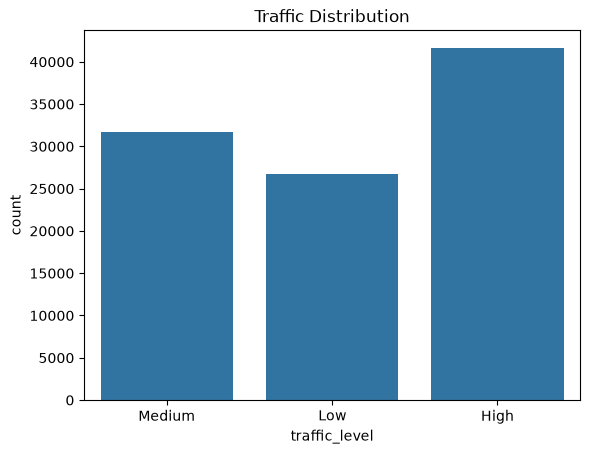

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='traffic_level', data=data)
plt.title("Traffic Distribution")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("traffic_data.csv")

# Clean data (noise remove / clip values)
df["vehicle_count"] = df["vehicle_count"].clip(10, 200)

#  Better feature engineering
df["rush_hour"] = df["time_of_day"].apply(lambda x: 1 if (7 <= x <= 10 or 17 <= x <= 20) else 0)

# Features
X = df[["vehicle_count","avg_speed","time_of_day","weather","rush_hour"]]
y = df["traffic_level"]

# Split (important: fixed random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Strong model tuning
model = RandomForestClassifier(
    n_estimators=200,     
    max_depth=10,         
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy*100:.2f}%")

# Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      8432
         Low       1.00      1.00      1.00      5290
      Medium       1.00      1.00      1.00      6278

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [8]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))